In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
print(sys.executable)

X_df = pd.read_pickle('../data/processed/X_df.pkl')
y_df = pd.read_pickle('../data/processed/y_df.pkl')

from sklearn.model_selection import GroupShuffleSplit

groups = X_df['WT_name']

splitter = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=42)


train_idx, test_idx = next(splitter.split(X_df, y_df, groups=groups))

X_train, X_test  = X_df.iloc[train_idx].copy(), X_df.iloc[test_idx].copy()
y_train, y_test = y_df.iloc[train_idx].copy(), y_df.iloc[test_idx].copy()

/Users/shanewarland/miniforge3/envs/protein-ml/bin/python


In [2]:
from src.features import get_biochemical_features

X_train = get_biochemical_features(X_train)
X_test = get_biochemical_features(X_test)

## Grab numeric columns
feature_cols = ["position", "relative_position", "protein_length",
    "wt_hydrophobicity", "mut_hydrophobicity", "delta_hydrophobicity", 
    "wt_mw", "mut_mw","delta_mw", 
    "wt_charge", "mut_charge", "delta_charge", "wt_aromatic", "mut_aromatic"]

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModel

model_name = "facebook/esm2_t6_8M_UR50D"

tokenizer = AutoTokenizer.from_pretrained(model_name)
esm_model = AutoModel.from_pretrained(model_name)

esm_model.eval()

In [4]:
sequence = X_train["aa_seq"].iloc[0]

tokens = tokenizer(
    sequence,
    return_tensors="pt"
)

with torch.no_grad():
    outputs = esm_model(**tokens)

print(outputs.last_hidden_state.shape)

torch.Size([1, 49, 320])


This is the embedding of 1 amino acid seqeunce. The 49 is the length of the amino acid sequence + 2 special tokens. The final dimension 320 is the embedding dimension for this mode. 

A first test is to get the embeddings for all WT and for all mut protein sequence and input these into lasso like regression to determine if the protein seqeunce even in a linear model can outperform a random forest. 

In [ ]:
from src.features import get_wt_seq

X_train = get_wt_seq(X_train)
X_test = get_wt_seq(X_test)
X_train.head()

Lets use the difference between the WT and the mut embeddings X_delta as inputs for ridge. To increase computational speed we will tap into my computer's GPUs. 

In [ ]:
print(torch.backends.mps.is_available())
device = torch.device("mps")

esm_model = esm_model.to(device)
esm_model.eval()

In [ ]:

from src.embeddings import get_residue_embeddings

## Get train/test mut/wt embeddings

train_mut_embeddings = get_residue_embeddings(
    X_train["aa_seq"].tolist(),
    X_train["position"].tolist(),
    tokenizer,
    esm_model,
    device,
    batch_size=128
)

train_wt_embeddings = get_residue_embeddings(
    X_train["wt_aa_seq"].tolist(),
    X_train["position"].tolist(),
    tokenizer,
    esm_model,
    device,
    batch_size=128
)

test_mut_embeddings = get_residue_embeddings(
    X_test["aa_seq"].tolist(),
    X_test["position"].tolist(),
    tokenizer,
    esm_model,
    device,
    batch_size=128
)

test_wt_embeddings = get_residue_embeddings(
    X_test["wt_aa_seq"].tolist(),
    X_test["position"].tolist(),
    tokenizer,
    esm_model,
    device,
    batch_size=128
)
print(train_mut_embeddings.shape)
print(test_mut_embeddings.shape)

torch.Size([312997, 320])

Now lets save them as that took a bit of time coputationally. I cut down time significantly by running on my computer's GPUs over CPUs. 

In [ ]:
torch.save(
    train_wt_embeddings,
    "../data/processed/train_wt_embeddings.pt"
)

torch.save(
    train_mut_embeddings,
    "../data/processed/train_mut_embeddings.pt"
)

torch.save(
    test_wt_embeddings,
    "../data/processed/test_wt_embeddings.pt"
)

torch.save(
    test_mut_embeddings,
    "../data/processed/test_mut_embeddings.pt"
)



Load in the data if needed. 

In [5]:
train_wt_embeddings = torch.load(
    "../data/processed/train_wt_embeddings.pt"
)

train_mut_embeddings = torch.load(
    "../data/processed/train_mut_embeddings.pt"
)

test_wt_embeddings = torch.load(
    "../data/processed/test_wt_embeddings.pt"
)

test_mut_embeddings = torch.load(
    "../data/processed/test_mut_embeddings.pt"
)

Now we can use the differences between the mut and wt embeddings as inputs for different models

In [6]:
train_delta_embeddings = train_mut_embeddings - train_wt_embeddings

test_delta_embeddings = test_mut_embeddings - test_wt_embeddings

X_train_esm = train_delta_embeddings.numpy()
X_test_esm = test_delta_embeddings.numpy()

## This will help with the ridge down the line
X_train_esm = X_train_esm.astype("float64")
X_test_esm = X_test_esm.astype("float64")

We use the embeddings to train out ridge model. Ridge can handle the high number of features from the embedings (320).

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, GroupKFold


## lsqr solver is more appropriate for our highly correlated matrix
ridge_esm = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(solver="lsqr"))])

param_grid = {
    "ridge__alpha": [0.1, 1, 10, 100, 1000]
}

cv = GroupKFold(n_splits=5)

ridge_search = GridSearchCV(
    ridge_esm,
    param_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1
)

ridge_search.fit(X_train_esm, y_train, groups=X_train["WT_name"])


print(ridge_search.best_params_)
#{'ridge__alpha': 1000}}

best_ridge = ridge_search.best_estimator_
y_pred = best_ridge.predict(X_test_esm)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)

rmse = mean_squared_error(y_test, y_pred) ** 0.5

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

from scipy.stats import spearmanr

rho, p_value = spearmanr(y_test, y_pred)

print("Spearman rho:", rho)
print("p-value:", p_value)

#MAE: 0.6508036618091843
#RMSE: 0.8469438025161423
#R²: 0.2822477499184254
#Spearman rho: 0.4933753585867847
#p-value: 0.0

MAE: 0.6508036618091843
RMSE: 0.8469438025161423
R²: 0.2822477499184254
Spearman rho: 0.4933753585867847
p-value: 0.0


Even though the embeddings for the ESM model were not trained using delta g labels, they still manage to outperform biochemical features in predicting protein stability when compared to the earlier ridge model (R² = .13). Ensemble based tree models like RF still outperform this (R² = 0.38), suggesting the nonlinear relationship between certain mutations and protein stability.

What about combining my biochemical data along with the embedding data? Does this model outperform the embeddings alone?

In [ ]:
import numpy as np

X_train_combined = np.hstack([
    X_train_esm,
    X_train[feature_cols].to_numpy()])

X_test_combined = np.hstack([
    X_test_esm,
    X_test[feature_cols].to_numpy()])

print(X_train_combined.shape)

Rerun Ridge using both datatypes

In [ ]:
## lsqr solver is more appropriate for our highly correlated matrix
ridge_esm = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(solver="lsqr"))])

param_grid = {
    "ridge__alpha": [0.1, 1, 10, 100, 1000]
}

cv = GroupKFold(n_splits=5)

ridge_search = GridSearchCV(
    ridge_esm,
    param_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1
)

ridge_search.fit(X_train_combined, y_train, groups=X_train["WT_name"])


print(ridge_search.best_params_)
#{'ridge__alpha': 1000}}

best_ridge = ridge_search.best_estimator_
y_pred = best_ridge.predict(X_test_combined)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

rmse = mean_squared_error(y_test, y_pred) ** 0.5

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)
rho, p_value = spearmanr(y_test, y_pred)
print("Spearman rho:", rho)
print("p-value:", p_value)
#MAE: 0.6433345369416963
#RMSE: 0.8389914834153779
#R²: 0.2956630401469005
#Spearman rho: 0.5018537219395691
#p-value: 0.0

MAE: 0.6433345369416963
RMSE: 0.8389914834153779
R²: 0.2956630401469005
Spearman rho: 0.5018537219395691
p-value: 0.0


Adding the biochemical data brings us up from R² = 0.282 to 0.296. This suggests there is additional information contained in the biochemical data, although a modest amount. 

Using Ridge is clearly not appropriate becuase the relationships are not linear. I will try and make a small neural network model that takes my mutational embeddings and makes a numerical prediction. I bet this will preform much better.

Have to redo the data. I want to split the training data into a training and validation set. Then I need to convert dtype back to float 32.

In [8]:
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import GroupShuffleSplit

## Create training split indices
groups = X_train['WT_name']
splitter = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=42)
train_idx, val_idx = next(splitter.split(X_train_esm, y_train, groups=groups))

## Split the training data
X_sub_train_esm, X_val_esm  = X_train_esm[train_idx].copy(), X_train_esm[val_idx].copy()
y_sub_train, y_val  = y_train.iloc[train_idx].copy(), y_train.iloc[val_idx].copy()

## Covert data to tensors with dtype float32
X_train_tensor = torch.tensor(X_sub_train_esm, dtype = torch.float32)
X_val_tensor = torch.tensor(X_val_esm, dtype = torch.float32)
X_test_tensor = torch.tensor(X_test_esm, dtype = torch.float32)
y_train_tensor = torch.tensor(y_sub_train.to_numpy(), dtype = torch.float32)
y_val_tensor = torch.tensor(y_val.to_numpy(), dtype = torch.float32)
y_test_tensor = torch.tensor(y_test.to_numpy(), dtype = torch.float32)

## Create the Tensor datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
validate_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

## Create the tensor dataloaders
train_dataloader = DataLoader(train_dataset, batch_size=256, shuffle=True)
validate_dataloader = DataLoader(validate_dataset, batch_size=256, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=256, shuffle=False)

I created a regression model. Lets use it to evalualate performance on train/val datasets

In [10]:
from src.models import EmbeddingRegressor, train_regression
from src.evaluate import evaluate_regression
from src.utils import set_seed

Epoch 1/100 complete. Train loss: 0.6872 Validation loss: 0.7076
Epoch 2/100 complete. Train loss: 0.6192 Validation loss: 0.6748
Epoch 3/100 complete. Train loss: 0.5901 Validation loss: 0.6770
Epoch 4/100 complete. Train loss: 0.5678 Validation loss: 0.6576
Epoch 5/100 complete. Train loss: 0.5496 Validation loss: 0.6513
Epoch 6/100 complete. Train loss: 0.5386 Validation loss: 0.6520
Epoch 7/100 complete. Train loss: 0.5250 Validation loss: 0.6450
Epoch 8/100 complete. Train loss: 0.5168 Validation loss: 0.6424
Epoch 9/100 complete. Train loss: 0.5070 Validation loss: 0.6438
Epoch 10/100 complete. Train loss: 0.5008 Validation loss: 0.6275
Epoch 11/100 complete. Train loss: 0.4930 Validation loss: 0.6320
Epoch 12/100 complete. Train loss: 0.4882 Validation loss: 0.6273
Epoch 13/100 complete. Train loss: 0.4804 Validation loss: 0.6313
Epoch 14/100 complete. Train loss: 0.4758 Validation loss: 0.6258
Epoch 15/100 complete. Train loss: 0.4709 Validation loss: 0.6237
Epoch 16/100 comple

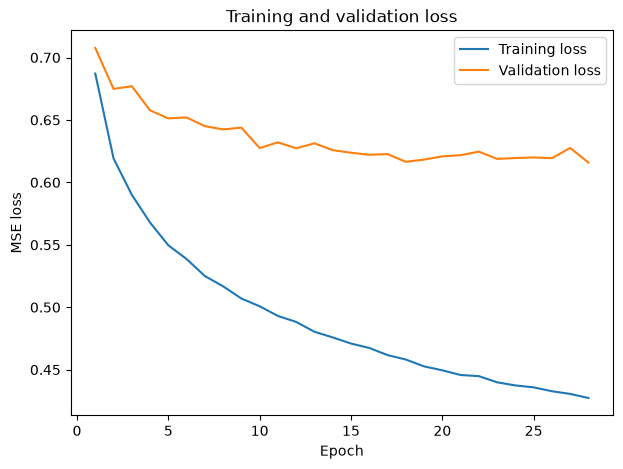

In [30]:


set_seed(42)

diagnostic_model = EmbeddingRegressor()

## Train diagnostic model
diagnostic_model, history = train_regression(
    dataloader=train_dataloader,
    model=diagnostic_model,
    num_epochs=100,
    lr=0.001,
    weight_decay=1e-4,
    validation_dataloader=validate_dataloader,
    patience=10,
    min_delta=0.001) 

epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(7, 5))
plt.plot(epochs, history["train_loss"], label="Training loss")
plt.plot(epochs, history["validation_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training and validation loss")
plt.legend()
#plt.tight_layout()
plt.savefig(
    "../figures/esm_net_training.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Interesting, ok so the model is learning the training data increasingly well (overfitting) but is plateauing at the validation set around epoch ~15.

In [ ]:
from src.evaluate import evaluate_regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import spearmanr
## The outputed model should be the best version

average_loss, all_predictions, all_targets = evaluate_regression(test_dataloader, diagnostic_model)

y_pred = all_predictions.numpy()
y_true = all_targets.numpy()

mae = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred) ** 0.5
r2 = r2_score(y_true, y_pred)
rho, p_value = spearmanr(y_true, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)
print("Spearman rho:", rho)
print("p-value:", p_value)
#MAE: 0.5520710945129395
#RMSE: 0.7432586569617128
#R²: 0.44722890853881836
#Spearman rho: 0.6437214118294614
#p-value: 0.0

MAE: 0.5520710945129395
RMSE: 0.7432586569617128
R²: 0.44722890853881836
Spearman rho: 0.6437214118294614
p-value: 0.0


Excellent, this is a pretty big improvement over the random forest and especially ridge. R² up to 0.45 compared to the 0.28 from Ridge using the embeddings. More importantly it emphasizes the nonlinear relationship between the embeddings. Save the model and we can move on to training a whole model.

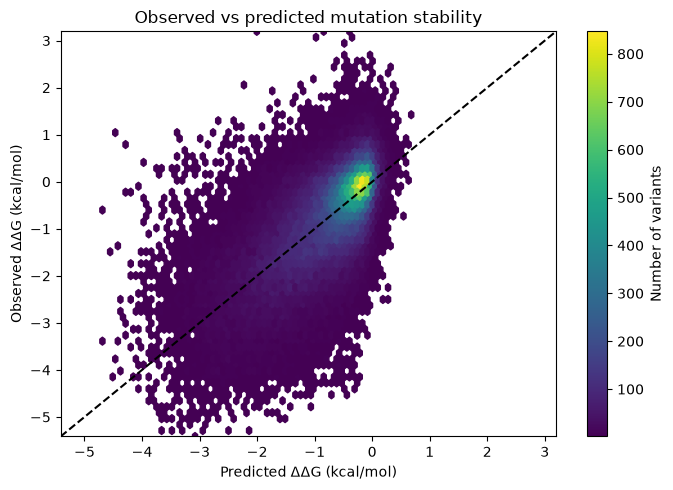

In [36]:
plt.figure(figsize=(7, 5))
plt.hexbin(
    y_pred,
    y_true,
    gridsize=60,
    mincnt=1,
    cmap="viridis"
)
plt.colorbar(label="Number of variants")

lims = [
    min(y_pred.min(), y_true.min()),
    max(y_pred.max(), y_true.max())
]

plt.plot(
    lims,
    lims,
    linestyle="--",
    color="black")

plt.xlim(lims)
plt.ylim(lims)

plt.xlabel("Predicted ΔΔG (kcal/mol)")
plt.ylabel("Observed ΔΔG (kcal/mol)")
plt.title("Observed vs predicted mutation stability")

plt.tight_layout()
plt.savefig(
    "../figures/esm_net_predresult.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



In [27]:
torch.save(
    diagnostic_model.state_dict(),
    "../data/processed/esm_embedding_net.pt"
)

Here I used the residue level embeddings from the ESM-2 model for both WT and mutant protein sequences. I constructed mutational representations based on the difference between the 320 dimension imbedding for the mut - wt residue in question and used it to predict the protein's stability. A linear ridge model achieved an R² of 0.28 on held-out proteins, and adding additional biochemical properties only resulted in a very modest R² increase to 0.29. Howver using a MLP on the same 320 embeddings resulted in a large jump to R² = 0.45. This highlights the nonlinear relationship of the protein mutations and the proteins stability. Next step is to apply transfer learning to adapt the ESM-2 model to predicting protein stability. 